# Ambient Weather Archive

This notebook downloads observations from an Ambient Weather station and maintains a local archive divided into **station-local calendar years**. It is intended for two audiences:

1. **Operational use:** update and backfill the NEIU weather-station archive.
2. **Instructional use:** show students how an authenticated REST API can be used to retrieve, validate, organize, and visualize environmental observations.

The reusable API and archive functions are kept in `ambient_weather.py`. This notebook supplies the station-specific configuration, documents the workflow, and provides a compact diagnostic plot. A separate analysis notebook can later provide more extensive QA/QC and visualization.

The current NEIU station is an Ambient Weather WS-5000 located on the roof of Bernard J. Brommel Hall (BBH) at Northeastern Illinois University.


## Notebook workflow

The notebook proceeds through the following steps:

1. Import the reusable functions from `ambient_weather.py`.
2. define the station metadata and archive locations;
3. authenticate with the Ambient Weather REST API;
4. list the devices associated with the account and confirm the selected station;
5. retrieve a small recent-data sample;
6. migrate the earlier single-file archive, if necessary;
7. update the archive with observations newer than the most recent local record;
8. optionally backfill older observations;
9. inventory the annual CSV files; and
10. plot a compact recent-weather summary.

Most users will run the **recent-data test** and **routine update** sections regularly. Historical backfilling is an occasional maintenance operation and is disabled by default.


## The Ambient Weather API

An **application programming interface (API)** allows one program to request data from another program using a documented set of URLs, parameters, and response formats. This notebook uses Ambient Weather's documented **REST API** directly through the Python `requests` package.

Ambient Weather requires two credentials for REST requests:

- `applicationKey` identifies the application making the request;
- `apiKey` grants read-only access to the past and present data associated with a user's devices.

The endpoint `/v1/devices` lists the devices available to the authenticated account and includes the latest observation from each device. Historical observations are requested from `/v1/devices/{macAddress}`, where the station's MAC address identifies the device.

Important details from the official documentation:

- historical timestamps are stored in UTC;
- historical results are returned in descending time order;
- `endDate` provides the cursor used to request earlier observations;
- a request returns at most 288 observations;
- archived observations occur at 5- or 30-minute intervals, depending on the device;
- requests are limited to one request per second for each user's API key.

The small client in `ambient_weather.py` implements these details, including request spacing, retries, pagination, conversion to a UTC `DatetimeIndex`, and duplicate removal.

### Official references

- [Ambient Weather REST API documentation](https://ambientweather.docs.apiary.io/)
- [Source repository for the API documentation](https://github.com/ambient-weather/api-docs)
- [Device Data Specifications](https://github.com/ambient-weather/api-docs/wiki/Device-Data-Specs)
- [Ambient Weather account page for API keys](https://ambientweather.net/account)


## Why use a small REST client rather than `ambient_api`?

Ambient Weather lists several community-maintained helper libraries, including Python wrappers. A wrapper can be convenient, but it also adds another dependency between this notebook and the documented web service. The REST interface is small enough that the essential operations can be implemented transparently with `requests`:

- list authorized devices;
- request one batch of observations;
- move backward through the record using `endDate`; and
- respect the documented rate limit.

Keeping these operations in `ambient_weather.py` makes the workflow easier to inspect, teach, test, and reuse in other notebooks. The module is not specific to NEIU or to the WS-5000; the station metadata remains in this notebook.


## Project files and dependencies

The notebook expects the following files in the same directory:

```text
ambient_weather.py
ambient_weather_archive.ipynb
README.md
```

Running the notebook creates annual CSV files and figures under:

```text
data/ambient/
figures/ambient/
```

Required Python packages:

- `pandas`
- `requests`
- `matplotlib`

The code also uses `IPython.display`, which is supplied with Jupyter.


In [ ]:
import os
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display

from ambient_weather import (
    AmbientWeatherClient,
    annual_archive_path,
    annual_archive_summary,
    backfill_annual_archive,
    fetch_recent_data,
    list_archive_years,
    migrate_single_csv_to_annual,
    read_annual_archive,
    update_annual_archive,
)

load_dotenv()

True

## Station and archive configuration

This is the principal station-specific cell. To use the notebook with another Ambient Weather station, change the station metadata, MAC address, time zone, and archive prefix here. The functions in `ambient_weather.py` do not contain NEIU-specific values.

The annual filenames describe the site and instrument category rather than the console model:

```text
neiu_weather_station_2021.csv
neiu_weather_station_2022.csv
...
```

This naming distinguishes the files from the NEIU Vaisala WXT files, which include `wxt` in their filenames, while remaining understandable to students who may not recognize the WS-5000 model number.


In [14]:
# Station metadata
DEVICE_MAC = "E8:DB:84:E1:CA:7F"
STATION_NAME = "NEIU Weather Station"
STATION_SITE = "BBH rooftop, Northeastern Illinois University"
STATION_TIMEZONE = "America/Chicago"
DEVICE_TYPE = "WS-5000"
PUBLIC_DASHBOARD_ID = "5dfc7e17641463aa116f6befeb44eb14"

# Local files
DATA_DIR = Path("data/ambient")
FIGURE_DIR = Path("figures/ambient")
ARCHIVE_PREFIX = "neiu_weather_station"
LEGACY_ARCHIVE_PATH = DATA_DIR / "neiu_ws5000.csv"

# Fields that should not be distributed in student archive CSVs.
ARCHIVE_DROP_COLUMNS = ("passkey", "loc")

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


## UTC timestamps and local archive years

The API supplies `dateutc` as milliseconds since the Unix epoch. The module converts it to a timezone-aware UTC index named `time_utc`.

UTC is retained in the CSV files because it is unambiguous, including during daylight-saving-time transitions. However, annual files are assigned using the station's **local calendar year**. For example, an observation at 8:00 p.m. CST on December 31 belongs in the December 31 archive even though its UTC timestamp falls on January 1.

This design provides both:

- a stable, unambiguous timestamp for analysis; and
- annual files that match the local calendar understood by students and station operators.


## Credentials and API client

API keys should not be stored in a notebook committed to GitHub. The following cell first checks two environment variables:

```text
AMBIENT_API_KEY
AMBIENT_APPLICATION_KEY
```

When either variable is missing, `getpass()` requests it without displaying the value on screen.

On Linux, the variables can be set temporarily before starting Jupyter:

```bash
export AMBIENT_API_KEY="your-api-key"
export AMBIENT_APPLICATION_KEY="your-application-key"
```

The `user_agent` string identifies the local application in HTTP requests; it is not an Ambient Weather credential.


In [15]:
AMBIENT_API_KEY = os.getenv("AMBIENT_API_KEY") or getpass(
    "Ambient Weather API key: "
)
AMBIENT_APPLICATION_KEY = os.getenv(
    "AMBIENT_APPLICATION_KEY"
) or getpass("Ambient Weather application key: ")

client = AmbientWeatherClient(
    api_key=AMBIENT_API_KEY,
    application_key=AMBIENT_APPLICATION_KEY,
    user_agent="NEIU-Atmospheric-Science-Lab/1.0",
)


## Confirm the selected device

The API key authorizes a **user account**, not a hard-coded station. The device-list endpoint may therefore return one or more devices associated with that account.

The following cell displays a compact device table and then verifies that exactly one device matches `DEVICE_MAC`. This prevents a mistyped MAC address from silently creating an empty or incorrect archive.


In [16]:
devices = client.list_devices()

rows = []
for item in devices:
    info = item.get("info") or {}
    last_data = item.get("lastData") or {}
    rows.append(
        {
            "mac_address": item.get("macAddress"),
            "name": info.get("name"),
            "location": info.get("location"),
            "latest_observation_utc": pd.to_datetime(
                last_data.get("dateutc"),
                unit="ms",
                utc=True,
                errors="coerce",
            ),
        }
    )

device_table = pd.DataFrame(rows)
display(device_table)

matching_devices = [
    item
    for item in devices
    if str(item.get("macAddress", "")).upper() == DEVICE_MAC.upper()
]

if len(matching_devices) != 1:
    raise RuntimeError(
        f"Expected exactly one match for {DEVICE_MAC}; "
        f"found {len(matching_devices)}."
    )

print(f"Confirmed: {STATION_NAME} ({DEVICE_MAC})")


,mac_address,name,location,latest_observation_utc
0,E8:DB:84:E1:CA:7F,NEIU Weather Station,None,2026-07-05 13:20:00+00:00


Confirmed: NEIU Weather Station (E8:DB:84:E1:CA:7F)


## Retrieve recent data without reading or updating the archive

Some notebooks need only a recent weather context. For example, a campus sap-flow notebook may retrieve the last 24 or 48 hours of solar radiation and place it behind the sap-flow record.

`fetch_recent_data()` requests enough API batches to cover the specified number of hours and returns a DataFrame indexed by UTC time. It does **not** modify the annual archive.

Historical observations may lag the most recent station report by several minutes. For genuinely up-to-the-minute monitoring, Ambient Weather also documents a realtime WebSocket API; the REST approach remains simpler for most notebook comparisons.


In [17]:
RUN_RECENT_TEST = True
RECENT_HOURS = 24

if RUN_RECENT_TEST:
    recent = fetch_recent_data(
        client,
        DEVICE_MAC,
        hours=RECENT_HOURS,
    )

    recent_summary = pd.Series(
        {
            "observations": len(recent),
            "first_time_utc": recent.index.min()
            if not recent.empty
            else pd.NaT,
            "last_time_utc": recent.index.max()
            if not recent.empty
            else pd.NaT,
            "number_of_fields": len(recent.columns),
        },
        name=f"recent_{RECENT_HOURS}_hours",
    )

    display(recent_summary)
    display(recent.tail())
else:
    print("Recent-data test skipped.")


observations                              288
first_time_utc      2026-07-04 13:25:00+00:00
last_time_utc       2026-07-05 13:20:00+00:00
number_of_fields                           35
Name: recent_24_hours, dtype: object

,dateutc,tempinf,humidityin,baromrelin,baromabsin,tempf,humidity,winddir,winddir_avg10m,windspeedmph,...,feelsLike,dewPoint,feelsLike1,dewPoint1,feelsLike2,dewPoint2,feelsLikein,dewPointin,lastRain,date
time_utc,,,,,,,,,,,,,,,,,,,,,
2026-07-05 13:00:00+00:00,1783256400000,75.2,75,29.980,29.980,66.9,97,342,339,6.0,...,66.9,66.02,76.3,65.6,76.0,65.3,75.9,66.7,2026-07-05T00:21:00.000Z,2026-07-05T13:00:00.000Z
2026-07-05 13:05:00+00:00,1783256700000,75.2,75,29.986,29.986,67.1,97,358,358,4.3,...,67.1,66.22,76.3,65.6,76.0,65.7,75.9,66.7,2026-07-05T00:21:00.000Z,2026-07-05T13:05:00.000Z
2026-07-05 13:10:00+00:00,1783257000000,75.2,76,29.980,29.980,67.3,98,37,0,2.2,...,67.3,66.71,76.4,66.0,76.0,65.7,76.0,67.1,2026-07-05T00:21:00.000Z,2026-07-05T13:10:00.000Z
2026-07-05 13:15:00+00:00,1783257300000,75.2,76,29.983,29.983,67.1,98,19,355,7.4,...,67.1,66.51,76.4,66.0,76.0,65.7,76.0,67.1,2026-07-05T00:21:00.000Z,2026-07-05T13:15:00.000Z
2026-07-05 13:20:00+00:00,1783257600000,75.4,76,29.988,29.988,67.1,98,24,16,6.7,...,67.1,66.51,76.4,66.0,76.2,65.9,76.2,67.3,2026-07-05T00:21:00.000Z,2026-07-05T13:20:00.000Z


## Raw Ambient Weather fields

Ambient Weather field names describe both the measured quantity and, often, the original unit. Not every device reports every possible field. Common WS-5000 fields include:

| Field | Meaning | API unit |
|---|---|---:|
| `tempf` | outdoor air temperature | °F |
| `humidity` | outdoor relative humidity | % |
| `dewPoint` | server-calculated dew point | °F |
| `windspeedmph` | instantaneous wind speed | mph |
| `windgustmph` | maximum wind speed over the preceding interval | mph |
| `winddir` | wind direction | degrees |
| `baromabsin` | absolute or station pressure | inHg |
| `baromrelin` | relative pressure | inHg |
| `solarradiation` | solar radiation | W m⁻² |
| `uv` | ultraviolet index | dimensionless |
| `hourlyrainin` | hourly rain rate | in h⁻¹ |
| `dailyrainin` | accumulated daily precipitation | in |

The annual archive preserves the API field names so the files remain traceable to the source documentation. The plotting section adds selected SI-unit columns without replacing the original values.

See the official [Device Data Specifications](https://github.com/ambient-weather/api-docs/wiki/Device-Data-Specs) for the complete field list and timing notes.


## Annual archive design

A separate CSV is maintained for each station-local calendar year. Annual files are practical for students because they are easy to download, inspect, and analyze independently, while several years can still be combined with `read_annual_archive()`.

The archive workflow follows three rules:

1. preserve the original API fields except for explicitly excluded internal fields;
2. retain one observation per UTC timestamp; and
3. rewrite files atomically so an interrupted write does not leave a partially written CSV.

The internal fields `passkey` and `loc` are excluded from the distributed archive. The earlier raw file can be retained privately if preserving the complete response is useful.


## Migrate the former single-file archive

An earlier version of the notebook wrote all observations to:

```text
data/ambient/neiu_ws5000.csv
```

If that file exists and no annual archive files are present, the following cell divides it into annual files. The legacy CSV is left unchanged, allowing it to serve as a backup during migration.


In [18]:
existing_years = list_archive_years(DATA_DIR, ARCHIVE_PREFIX)

if LEGACY_ARCHIVE_PATH.exists() and not existing_years:
    migrated_paths = migrate_single_csv_to_annual(
        LEGACY_ARCHIVE_PATH,
        DATA_DIR,
        ARCHIVE_PREFIX,
        STATION_TIMEZONE,
        drop_columns=ARCHIVE_DROP_COLUMNS,
    )
    print("Migrated legacy archive:")
    for path in migrated_paths:
        print(f"  {path}")
elif existing_years:
    print(f"Annual archive already contains: {existing_years}")
else:
    print("No legacy archive was found; the first update will create one.")


Annual archive already contains: [2026]


## Routine archive update

This is the normal maintenance operation. The updater:

1. finds the newest timestamp already stored in the annual files;
2. requests observations from the API, moving backward as needed;
3. retains only observations newer than the archive cutoff;
4. assigns each observation to its local calendar year; and
5. merges, sorts, deduplicates, and atomically rewrites the affected files.

Set `RUN_UPDATE = False` when reading the notebook without contacting the API or when demonstrating later sections from an existing archive.


In [19]:
RUN_UPDATE = True

if RUN_UPDATE:
    new_observations = update_annual_archive(
        client,
        DEVICE_MAC,
        DATA_DIR,
        ARCHIVE_PREFIX,
        STATION_TIMEZONE,
        drop_columns=ARCHIVE_DROP_COLUMNS,
    )

    print(
        f"Archive update complete: {new_observations:,} "
        "observations downloaded."
    )
else:
    print("Routine archive update skipped.")

display(
    annual_archive_summary(
        DATA_DIR,
        ARCHIVE_PREFIX,
        STATION_TIMEZONE,
    )
)


Archive update complete: 2 observations downloaded.


observations                             1846
first_time_utc      2026-06-29 03:35:00+00:00
last_time_utc       2026-07-05 13:20:00+00:00
first_time_local    2026-06-28 22:35:00-05:00
last_time_local     2026-07-05 08:20:00-05:00
archive_years                            2026
number_of_files                             1
Name: archive, dtype: object

## Historical backfill

Backfilling moves backward from the earliest archived observation and is intended for building or repairing the historical archive. It can require many API calls because each historical request returns no more than 288 observations.

For safety, backfilling is disabled by default:

```python
RUN_BACKFILL = False
```

A limited test can be run by setting `RUN_BACKFILL = True` while keeping `MAX_BACKFILL_BATCHES = 5`. After confirming that the results are correct, set `MAX_BACKFILL_BATCHES = None` to continue until the API returns no earlier records or the optional `BACKFILL_START` date is reached.

A date such as `"2021-01-01"` is interpreted in the station time zone. The module periodically checkpoints downloaded data so a long operation does not need to remain entirely in memory.


In [ ]:
RUN_BACKFILL = False
BACKFILL_START = None
MAX_BACKFILL_BATCHES = 5 # None

if RUN_BACKFILL:
    older_observations = backfill_annual_archive(
        client,
        DEVICE_MAC,
        DATA_DIR,
        ARCHIVE_PREFIX,
        STATION_TIMEZONE,
        start_date=BACKFILL_START,
        drop_columns=ARCHIVE_DROP_COLUMNS,
        max_batches=MAX_BACKFILL_BATCHES,
    )

    print(
        f"Backfill pass complete: {older_observations:,} "
        "observations downloaded."
    )
else:
    print("Historical backfill skipped.")

display(
    annual_archive_summary(
        DATA_DIR,
        ARCHIVE_PREFIX,
        STATION_TIMEZONE,
    )
)


Backfill pass complete: 170,934 observations downloaded.


observations                           174220
first_time_utc      2024-11-01 18:53:00+00:00
last_time_utc       2026-07-05 13:20:00+00:00
first_time_local    2024-11-01 13:53:00-05:00
last_time_local     2026-07-05 08:20:00-05:00
archive_years                2024, 2025, 2026
number_of_files                             3
Name: archive, dtype: object

## Annual archive inventory

The inventory below reports each annual file's coverage, size, duplicate count, and median sampling interval. The observation count is not interpreted as a completeness score because the first and final years may contain only partial records and stations can experience outages.

A more detailed analysis notebook can compare observed timestamps with an expected five-minute grid, identify gaps, and distinguish missing reports from small timing offsets.


In [21]:
inventory_rows = []

for year in list_archive_years(DATA_DIR, ARCHIVE_PREFIX):
    path = annual_archive_path(DATA_DIR, ARCHIVE_PREFIX, year)
    time_column = pd.read_csv(path, usecols=["time_utc"])
    times = pd.to_datetime(time_column["time_utc"], utc=True, errors="raise")
    local_times = times.dt.tz_convert(STATION_TIMEZONE)
    intervals = times.sort_values().diff().dt.total_seconds().div(60)

    inventory_rows.append(
        {
            "year": year,
            "file": path.name,
            "observations": len(times),
            "first_time_local": local_times.min(),
            "last_time_local": local_times.max(),
            "median_interval_minutes": intervals.median(),
            "duplicate_timestamps": int(times.duplicated().sum()),
            "size_mb": path.stat().st_size / 1_000_000,
        }
    )

archive_inventory = pd.DataFrame(inventory_rows)
display(archive_inventory)


,year,file,observations,first_time_local,last_time_local,median_interval_minutes,duplicate_timestamps,size_mb
0,2026,neiu_weather_station_2026.csv,1846,2026-06-28 22:35:00-05:00,2026-07-05 08:20:00-05:00,5.0,0,0.454944


## SI-unit columns and compact visualization

The archive preserves the API's original units. The helper below creates additional SI-unit columns for visualization:

- degrees Fahrenheit → degrees Celsius;
- miles per hour → metres per second;
- inches of mercury → hectopascals; and
- inches of precipitation → millimetres.

These derived columns are created in memory and are not written back to the annual CSV files.

The resulting plot is a compact operational check, not the final analysis product. It can reveal implausible values, long gaps, or an archive that failed to update. A later `ambient_weather_analysis.ipynb` can add synchronized interactive graphs, precipitation summaries, wind roses, and formal QA/QC.

**Pressure caveat:** the uploaded sample showed identical `baromabsin` and `baromrelin` values. Relative pressure should therefore remain provisional until the station elevation and pressure correction are checked at the console.


In [22]:
def add_si_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with commonly used variables converted to SI units."""
    result = frame.copy()

    temperature_fields = {
        "tempf": "temperature_c",
        "dewPoint": "dew_point_c",
        "tempinf": "indoor_temperature_c",
    }
    for source, target in temperature_fields.items():
        if source in result:
            result[target] = (
                pd.to_numeric(result[source], errors="coerce") - 32.0
            ) * 5.0 / 9.0

    wind_fields = {
        "windspeedmph": "wind_speed_ms",
        "windgustmph": "wind_gust_ms",
    }
    for source, target in wind_fields.items():
        if source in result:
            result[target] = (
                pd.to_numeric(result[source], errors="coerce") * 0.44704
            )

    pressure_fields = {
        "baromabsin": "station_pressure_hpa",
        "baromrelin": "relative_pressure_hpa",
    }
    for source, target in pressure_fields.items():
        if source in result:
            result[target] = (
                pd.to_numeric(result[source], errors="coerce")
                * 33.8638866667
            )

    rain_fields = {
        "hourlyrainin": "hourly_rain_mm",
        "dailyrainin": "daily_rain_mm",
    }
    for source, target in rain_fields.items():
        if source in result:
            result[target] = (
                pd.to_numeric(result[source], errors="coerce") * 25.4
            )

    return result


def plot_weather_summary(
    frame: pd.DataFrame,
    *,
    days: int = 7,
    save: bool = False,
) -> tuple[plt.Figure, list[plt.Axes]]:
    """Plot a recent-weather summary in station local time."""
    if frame.empty:
        raise ValueError("No observations are available to plot.")
    if days < 1:
        raise ValueError("days must be at least 1.")

    data = add_si_columns(frame)
    end_time = data.index.max()
    data = data.loc[
        data.index >= end_time - pd.Timedelta(days=days)
    ].copy()
    data.index = data.index.tz_convert(STATION_TIMEZONE)

    panel_definitions = [
        (
            ["temperature_c", "dew_point_c"],
            ["Air temperature", "Dew point"],
            "Temperature (°C)",
        ),
        (["humidity"], ["Relative humidity"], "Relative humidity (%)"),
        (
            ["wind_speed_ms", "wind_gust_ms"],
            ["Wind speed", "Wind gust"],
            "Wind speed (m s$^{-1}$)",
        ),
        (
            ["station_pressure_hpa", "relative_pressure_hpa"],
            ["Station pressure", "Relative pressure (provisional)"],
            "Pressure (hPa)",
        ),
        (
            ["solarradiation"],
            ["Solar radiation"],
            "Solar radiation (W m$^{-2}$)",
        ),
        (["hourly_rain_mm"], ["Hourly rain rate"], "Rain rate (mm h$^{-1}$)"),
    ]

    available_panels = []
    for fields, labels, ylabel in panel_definitions:
        available = [
            (field, label)
            for field, label in zip(fields, labels)
            if field in data.columns
        ]
        if available:
            available_panels.append((available, ylabel))

    if not available_panels:
        raise ValueError(
            "None of the expected plotting fields are available."
        )

    figure, axes_array = plt.subplots(
        len(available_panels),
        1,
        figsize=(11, 2.4 * len(available_panels)),
        sharex=True,
        constrained_layout=True,
    )
    axes = (
        list(axes_array)
        if len(available_panels) > 1
        else [axes_array]
    )

    for axis, (series, ylabel) in zip(axes, available_panels):
        for field, label in series:
            axis.plot(
                data.index,
                pd.to_numeric(data[field], errors="coerce"),
                label=label,
            )
        axis.set_ylabel(ylabel)
        axis.grid(alpha=0.3)
        if len(series) > 1:
            axis.legend(loc="best")

    axes[-1].set_xlabel(f"Time ({STATION_TIMEZONE})")
    figure.suptitle(f"{STATION_NAME}: most recent {days} days")

    if save:
        local_end = end_time.tz_convert(STATION_TIMEZONE)
        output_path = FIGURE_DIR / (
            f"neiu_weather_station_summary_{local_end:%Y-%m-%d}.png"
        )
        figure.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"Saved figure: {output_path}")

    return figure, axes


Saved figure: figures/ambient/neiu_weather_station_summary_2026-07-05.png


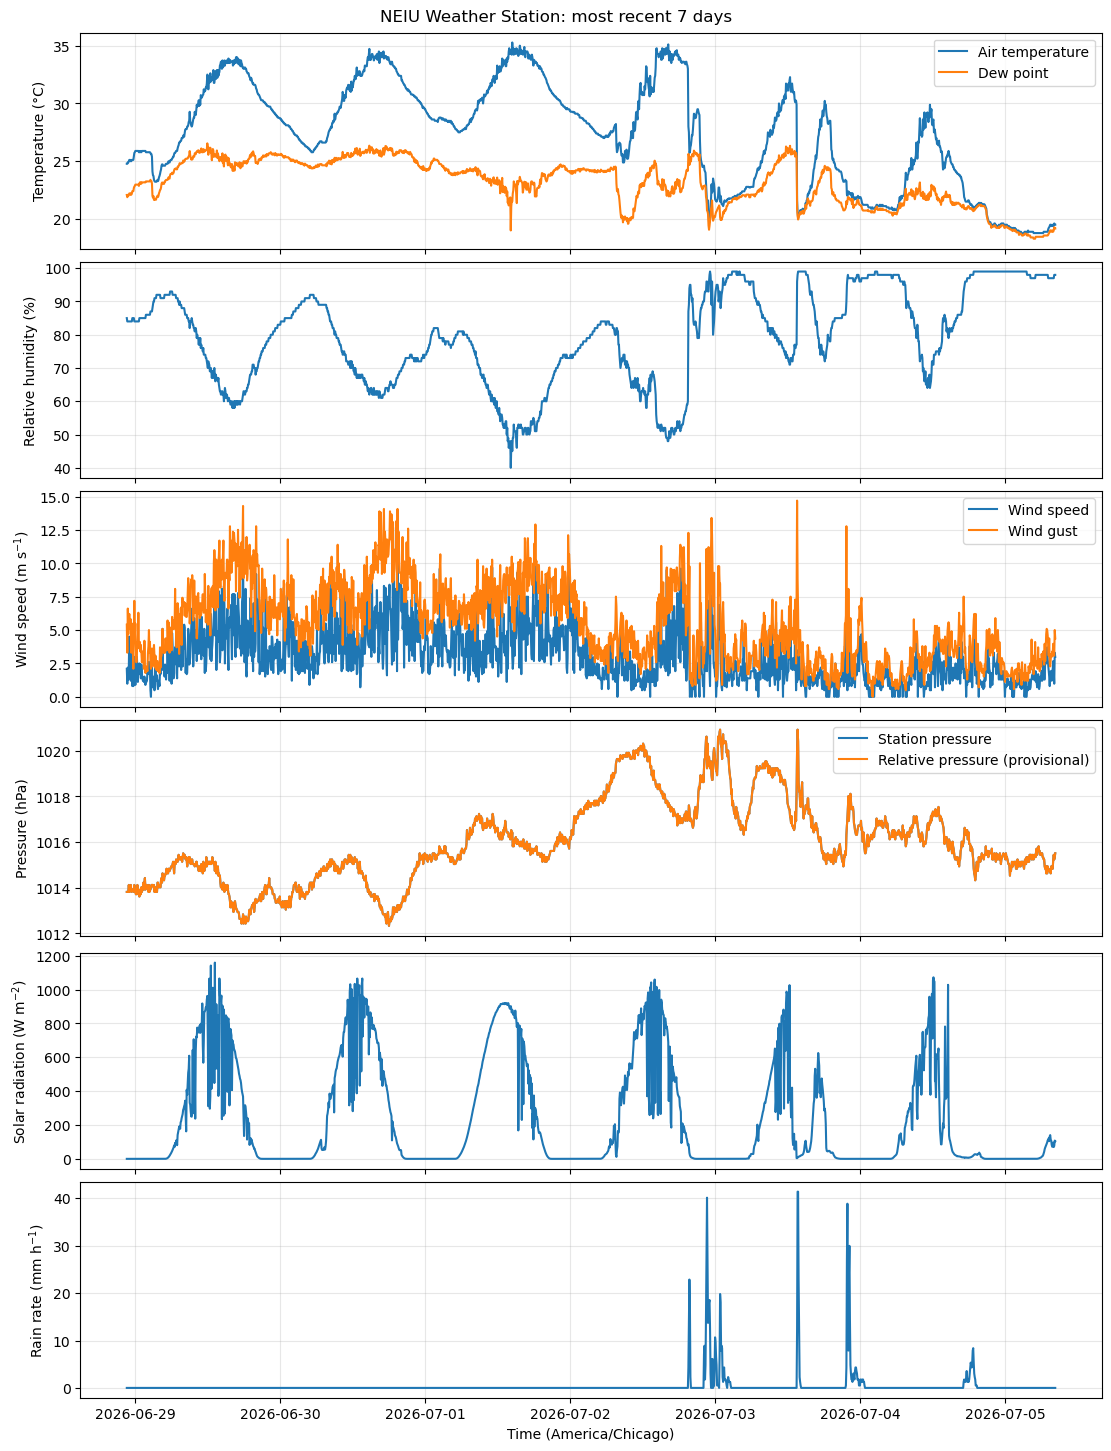

In [23]:
archive_years = list_archive_years(DATA_DIR, ARCHIVE_PREFIX)

if not archive_years:
    raise RuntimeError("No annual archive files are available to plot.")

# Two years suffice when the most recent seven days cross New Year.
recent_archive = read_annual_archive(
    DATA_DIR,
    ARCHIVE_PREFIX,
    years=archive_years[-2:],
)

figure, axes = plot_weather_summary(
    recent_archive,
    days=7,
    save=True,
)
plt.show()


## Reuse from another notebook

`ambient_weather.py` is intended to support other meteorological and ecological notebooks in this directory. A notebook that needs recent radiation data can use the same client without reading or changing the annual archive:

```python
from ambient_weather import AmbientWeatherClient, fetch_recent_data

client = AmbientWeatherClient(API_KEY, APPLICATION_KEY)
weather = fetch_recent_data(client, DEVICE_MAC, hours=48)
solar_radiation = weather["solarradiation"]
```

The returned index is UTC. Convert it only when a local-time display or comparison requires it:

```python
weather_local = weather.tz_convert("America/Chicago")
```

For research workflows, it is usually safest to keep source data in UTC and convert all compared datasets to a common time zone immediately before alignment or plotting.


## Known issues and future work

The archive notebook intentionally performs only limited interpretation. Items for later work include:

- verify the station elevation and relative-pressure correction at the WS-5000 console;
- document the purpose and placement of auxiliary temperature/humidity channels;
- construct formal completeness flags on a five-minute time grid;
- identify persistent values, physical-range failures, and sensor outages;
- calculate daily and monthly summaries with completeness thresholds;
- compare the Ambient Weather station with the rooftop Vaisala WXT;
- build interactive graphics inspired by the Ambient Weather dashboard; and
- create documented subsets for student exercises.

A future `ambient_weather_analysis.ipynb` should read the annual CSV files rather than contact the API. That separation keeps data acquisition reproducible and prevents exploratory analysis from accidentally modifying the archive.
